## Ściągnięcie danych oraz ich przegląd

**Proszę odkomentować i wykonać poniższą komórkę jeśli używają państwo Colaba lub MyBinder!**

In [91]:
# import os
# if not os.path.exists('utils.py'):
#     !curl -O https://raw.githubusercontent.com/NXTRSS/MachineLearningCourse/main/utils.py
# from utils import check_and_download_data

# check_and_download_data(files_to_check=["data_houses"])

##### Ściągnięcie wszystkich niezbędbych bibliotek

In [92]:
# === Konfiguracja środowiska ===
# Pakiety są już zainstalowane (Docker/uv).
# Na Colabie — odkomentuj poniższe linie jeśli coś brakuje:
# !pip install -q pandas scikit-learn matplotlib


In [93]:
!python --version

Python 3.9.20


In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn import metrics
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
import matplotlib.patches as mpatches
import plotly.express as px
import plotly.graph_objects as go
import os
from scipy import stats


from utils import bcolors


##### Sciągnięcie danych

In [95]:
import os

if os.path.exists("data_houses.csv"):
    df = pd.read_table("data_houses.csv", sep=",")
else:
    print("Plik lokalny nie znaleziony — pobieram z GitHub...")
    url = "https://raw.githubusercontent.com/NXTRSS/MachineLearningCourse/main/data_houses.csv"
    df = pd.read_table(url, sep=",")
    print("OK")

Plik lokalny nie znaleziony — pobieram z GitHub...
OK


##### Wypisać rozmiar danych (liczbę wierszy i liczbę kolumn)

In [96]:
# Tutaj wpisz swój kod


###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [97]:
df.shape

(21613, 21)

###### <span style="font-family:Monospace">(21613, 21)</span>

##### Wypisać 10 pierwszych lini danych

In [98]:
# Tutaj wpisz swój kod


###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [99]:
#rozwiązanie
df.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


###### <div>
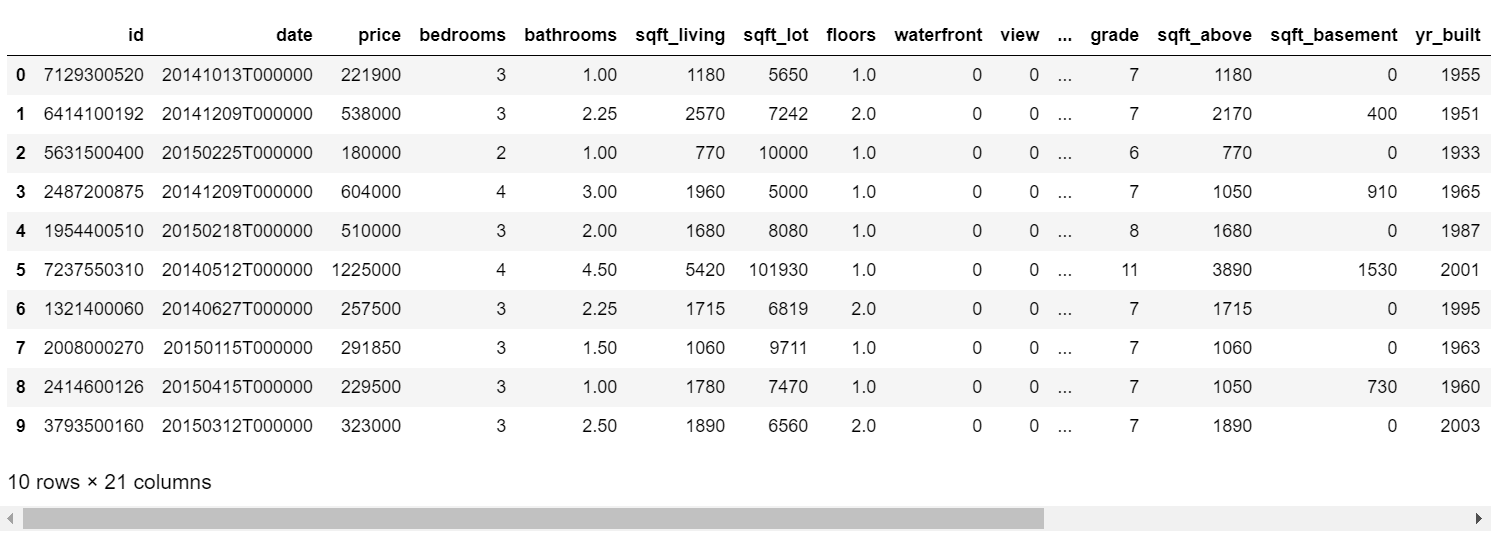
</div>

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  int64  
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

Ponieważ ściągnięte dane są dosyć "czyste" nie będziemy musieli przeprowadzać czyszczenia danych, preprocessingu <br> <br>
Naszym celem będzie predykowanie jednej zmiennej (zmienna objaśniana) y - **price** czyli po prostu cena mieszkania <br>
Do naszego zadania będziemy używać tylko dwóch zmiennych objaśniających: x - **bedrooms** oraz **sqft_living**

##### Wypisać średnią i medianę zmiennej price

In [101]:
# Tutaj wpisz swój kod


###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [102]:
#rozwiązanie
print('Mean',round(df['price'].mean(),2))
print('Median',df['price'].median())

Mean 540088.14
Median 450000.0


###### 
<span style="font-family:Monospace"> Mean 540088.14 <br>
<span style="font-family:Monospace"> Median 450000.0 <br>
</span>

## Wizualizacje

###### Wyrysować histogram ceny - zmiennej objaśnianej (price)

In [103]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Skorzystaj z `sns.histplot()`. Aby dodać krzywą gęstości użyj parametru `kde=True`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<Axes: xlabel='price', ylabel='Density'>

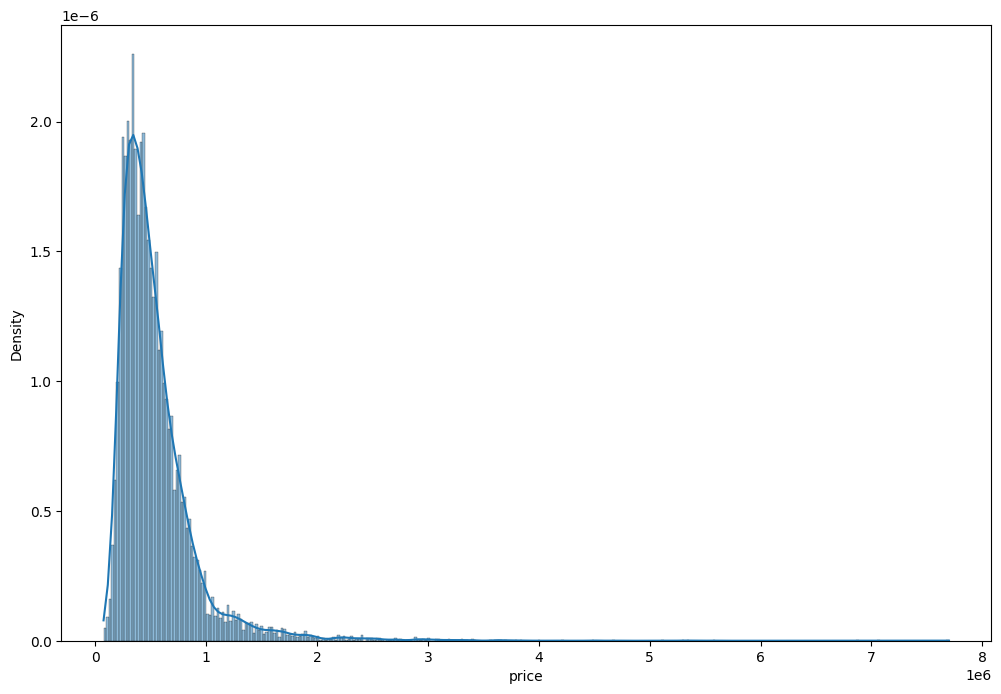

In [104]:
#przykładowe rozwiązanie
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(12,8))
sns.histplot(df['price'], kde=True, stat='density', label='price')

###### Wyrysować histogram powierzchni mieszkania - zmiennej objaśniającej (sqft_living)

In [105]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Tak samo jak poprzedni histogram — skorzystaj z `sns.histplot()`. Tym razem zmienna to `sqft_living`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<Axes: xlabel='sqft_living', ylabel='Count'>

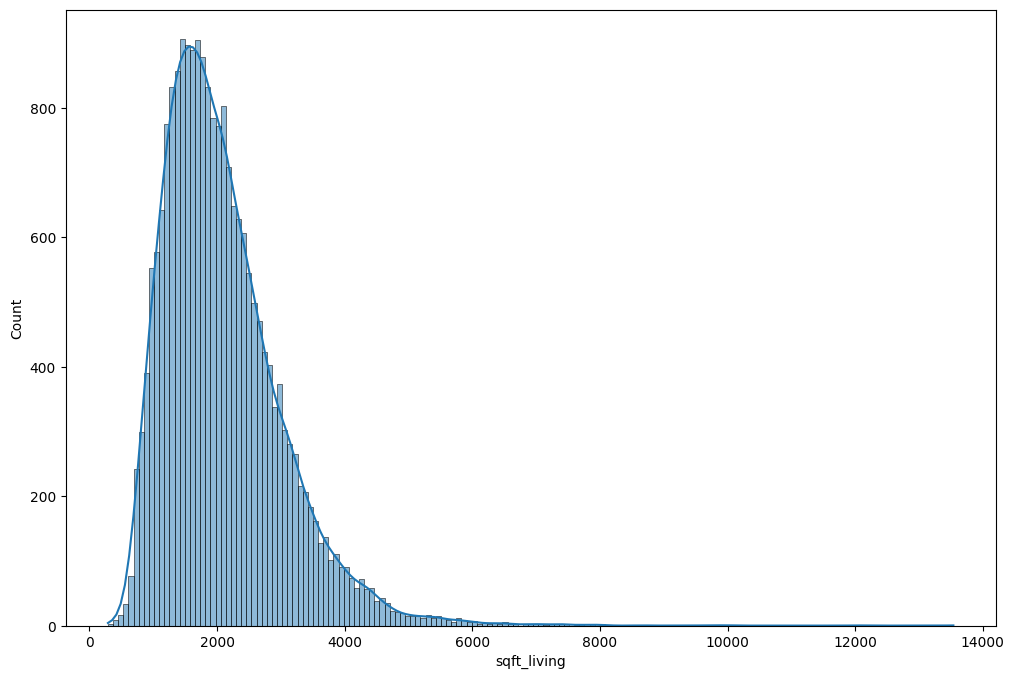

In [106]:
#przykładowe rozwiązanie
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(12,8))
sns.histplot(df['sqft_living'], kde=True)

###### Wyrysować wykres słupkowy liczby sypialni - zmiennej objaśniającej (bedrooms)

In [107]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Nie potrzebujesz średniej — chcesz policzyć ile razy pojawia się każda wartość.
Skorzystaj z `sns.countplot()`. Pamiętaj o parametrach `data=df` i `x='bedrooms'`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

<Axes: xlabel='bedrooms', ylabel='count'>

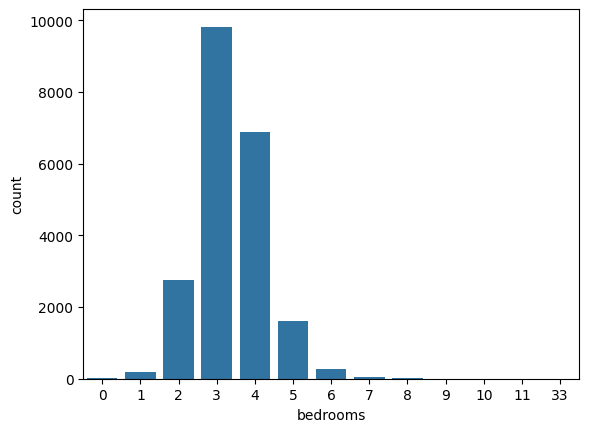

In [108]:
#przykładowe rozwiązanie
sns.countplot(data=df, x='bedrooms')

### Dodatkowe wizualizacje

Zależność ceny od powierzchni mieszkania - widać, że czym większe mieszkanie tym większa cena

/var/folders/ks/3dbjt_cx7md2qxfwmjytytk40000gn/T/ipykernel_3488/3742081905.py:5: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



<Axes: title={'center': 'house prices by sqft_living'}, xlabel='sqft_living', ylabel='house prices'>

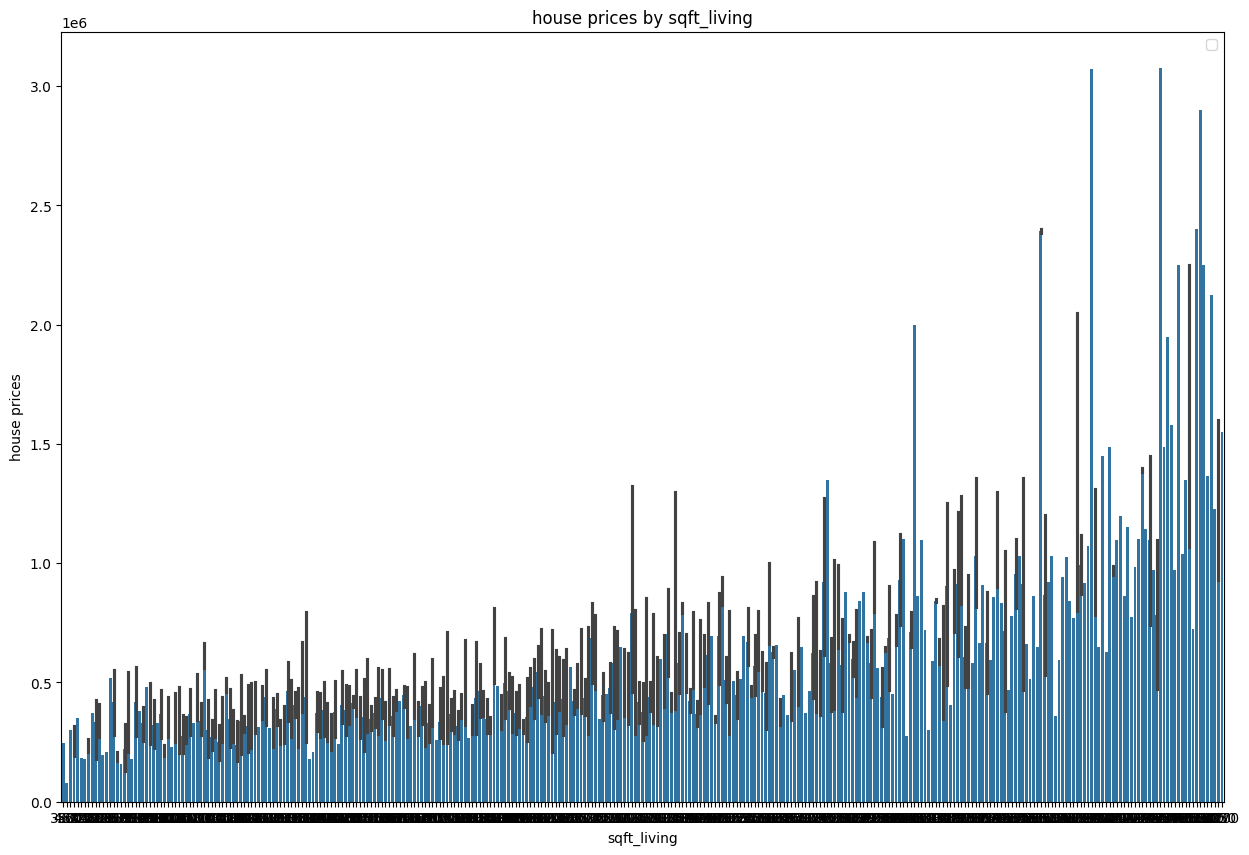

In [109]:
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(15,10))
plt.title("house prices by sqft_living")
plt.xlabel('sqft_living')
plt.ylabel('house prices')
plt.legend()
sns.barplot(x='sqft_living',y='price',data=df.iloc[:1000,:])

Wartości korelacji liniowej między zmiennymi - mogą służyć do wyboru zmiennych objaśniających użytych do modelu **regresji liniowej**

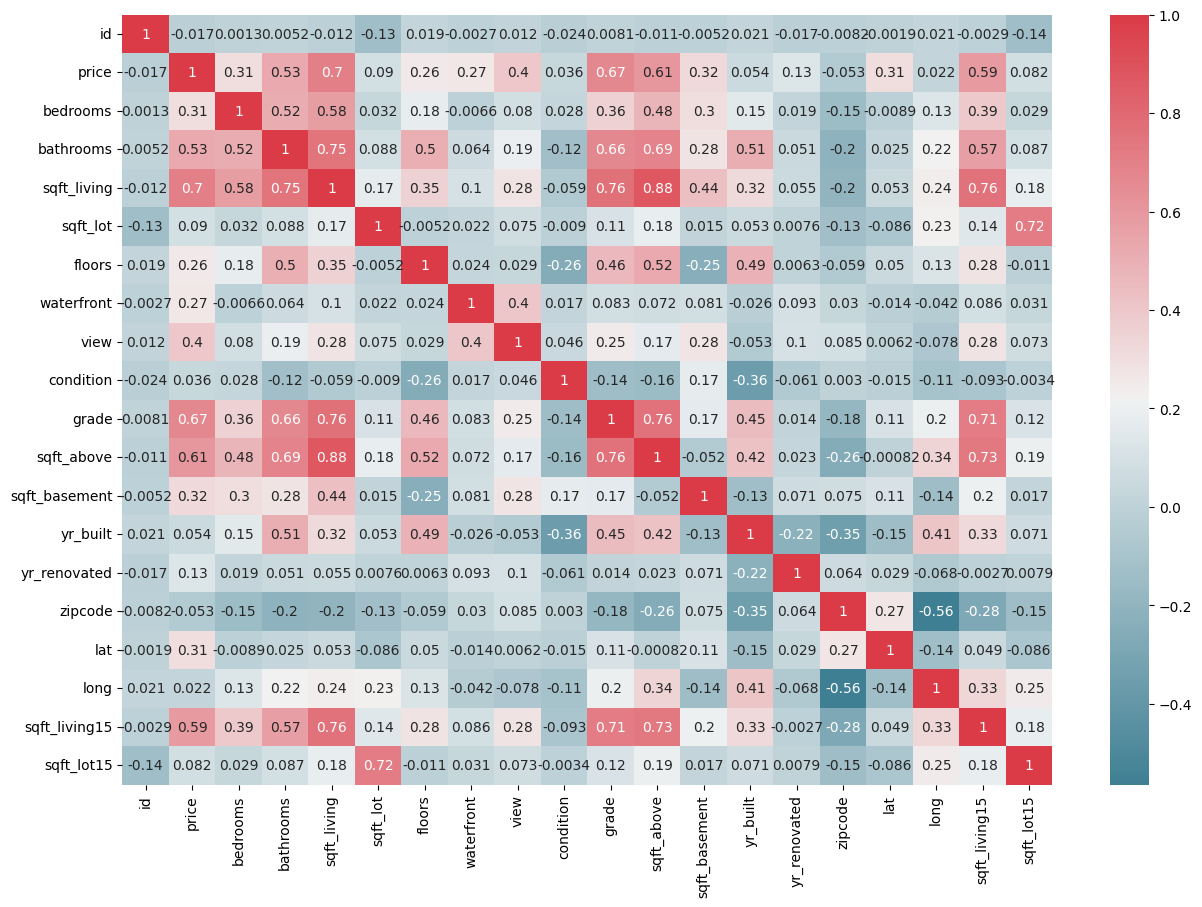

In [110]:
def correlation_heatmap(df1):
    _,ax=plt.subplots(figsize=(15,10))
    colormap=sns.diverging_palette(220,10,as_cmap=True)
    sns.heatmap(df1.select_dtypes(include="number").corr(), annot=True, cmap=colormap)
    
correlation_heatmap(df)

Wykresy pudełkowe dla kilku **zmiennych kategorycznych**

<Axes: xlabel='bathrooms', ylabel='price'>

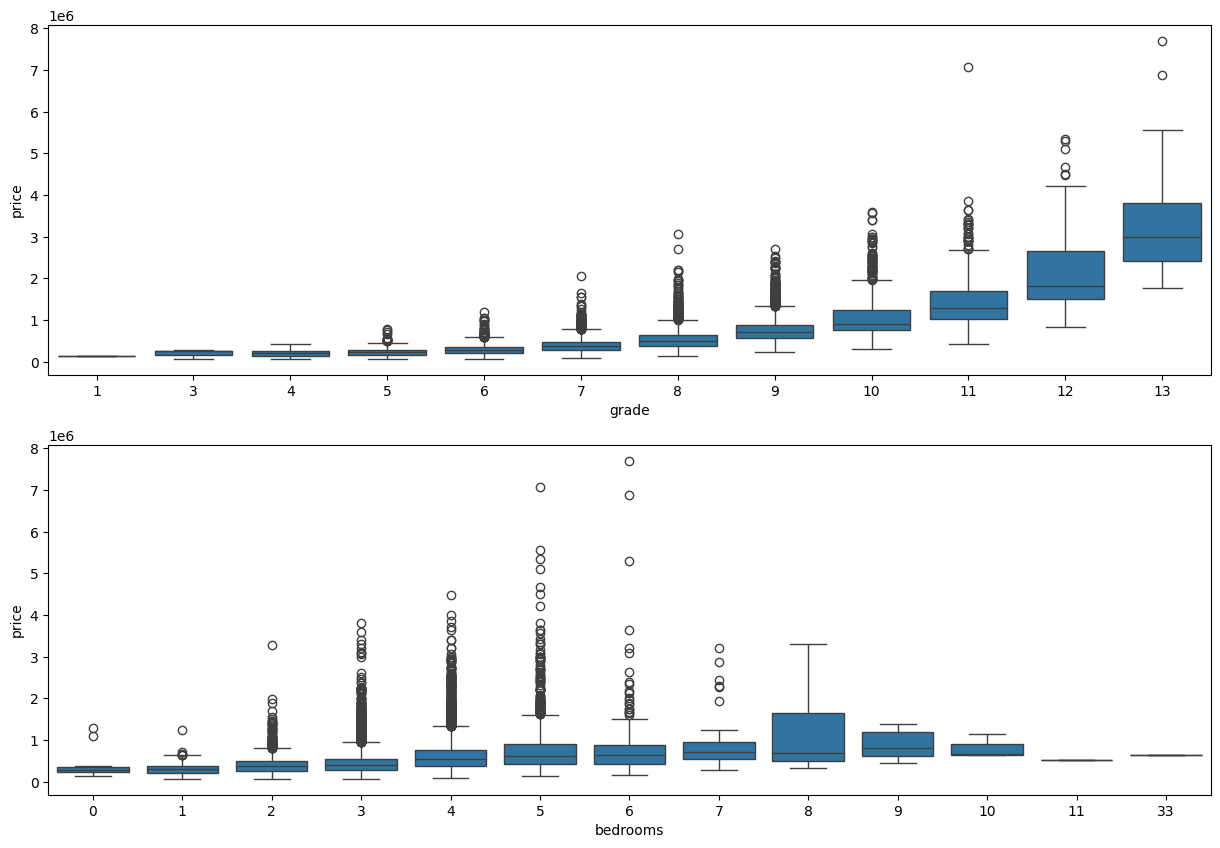

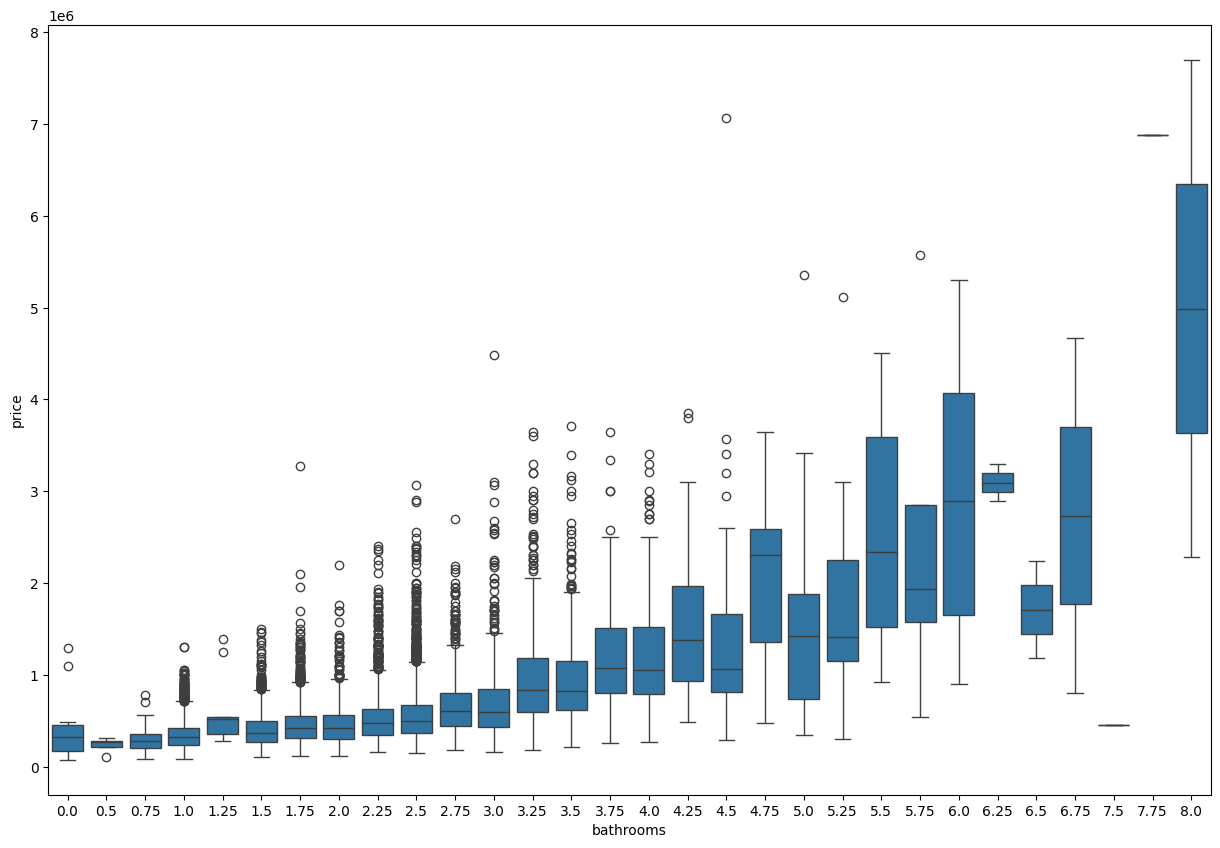

In [111]:
fig,ax=plt.subplots(2,1,figsize=(15,10))
sns.boxplot(x=df['grade'],y=df['price'],ax=ax[0])
sns.boxplot(x=df['bedrooms'],y=df['price'],ax=ax[1])
_ , axes = plt.subplots(1, 1, figsize=(15,10))
sns.boxplot(x=df['bathrooms'],y=df['price'])

## Regresja liniowa - wersja 2D

W tej wersji będziemy używać tylko jednej zmiennej objaśniającej - powierzchni mieszkani (sqft_living) i będziemy starali się wypredykować cenę (price)

##### Wyrysywać wykres (2D) powierzchni i ceny

In [112]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Skorzystaj z `plt.scatter(x, y)`. Pamiętaj o `plt.xlabel()` i `plt.ylabel()` żeby opisać osie.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Text(0, 0.5, 'price')

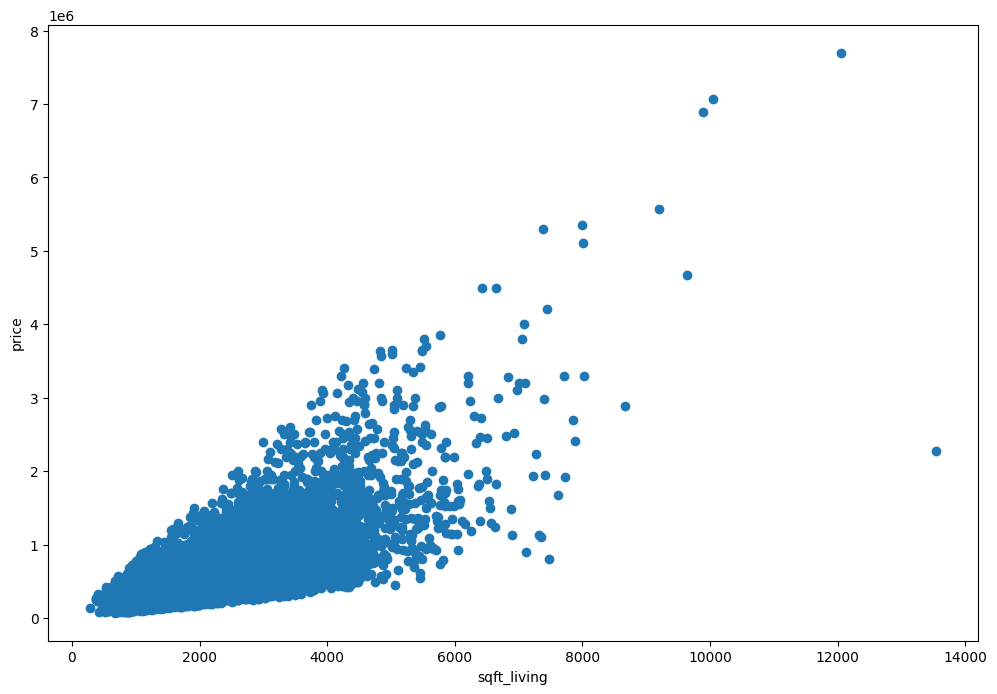

In [113]:
#przykładowe rozwiązanie
fig,axes=plt.subplots(nrows=1,ncols=1,figsize=(12,8))
plt.scatter(df['sqft_living'], df['price'])
plt.xlabel('sqft_living')
plt.ylabel('price')

###### Robocza funckja do rysowania Scatter-plot'a wraz z informacją o gęstości pomiarów


In [114]:
def scatter_with_density(data, x, y):
    x_name, y_name = x, y
    x = data[x]
    y = data[y]
    values = np.vstack([x, y])
    kernel = stats.gaussian_kde(values)(values)
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(
        data=data,
        x=x_name,
        y=y_name,
        c=kernel,
        cmap="viridis",
        ax=ax,
    )

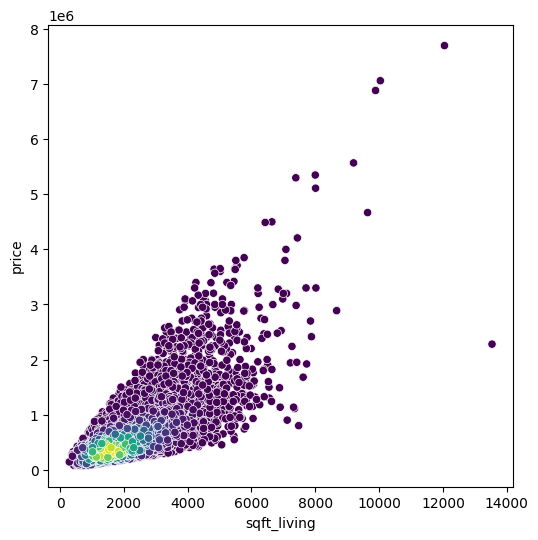

In [115]:
scatter_with_density(data=df, x='sqft_living', y='price')

##### Trenownie modelu

Przypomnienie z liceum: liniowy model wygląda następująco: $$\hat{y} = a \cdot x + b$$ W postaci bardziej ogólnej (za chwilę będziemy używać wielomianów) : $$\hat{y} = a_1 \cdot x + a_0$$  $a_1$ oraz $a_0$ to **parametry** modelu - to miejsce gdzie znajduje się cała "wiedza" modelu.  Teraz zdefiniujmy funkcję kosztu - MSE (mean squared error): $$J = \frac{1}{n} \sum_{i=1}^{n} (\hat{y} - y)^2$$ Czym większa będzie różnica między $\hat{y}$ (czyli ceną predykowaną przez nasz model) a $y$ (czyli prawdziwą ceną) - tym większy będzie błąd/funkcja kosztu. To co chcemy zrobić to znaleźć minimum tej funckji. I tutaj z pomocą przychodzi analiza matematyczna oraz pochodne - musimy wyzerować pochodną tej funkcji. Przypomnienie pochodnych na przykładzie funkcji kwadratowej:

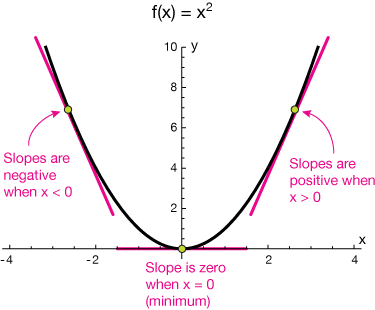

Po przyrównaniu pochodnej do zera możemy analitycznie wyliczyć wartości parametrów w zależności od y i x:
$$ a_1 = \frac{\sum (x-\bar{x})(y-\bar{y})}{\sum (x-\bar{x})^2} = \frac{\sum (xy) - n\bar{x}\bar{y}}{\sum x^2 - n\bar{x}\bar{x}} $$ $$ a_0 = \bar{y} - a_1\bar{x}$$ gdzie $\bar{x}$ to średnia ze zmiennej x a $\bar{y}$ to średnia ze zmiennej y

##### Proszę wyliczyć $a_0$ oraz $a_1$ na podstawie powyższych wzorów

In [116]:
x = df['sqft_living']
y = df['price']
n = len(x)

# proszę poniżej kontynuować kod

In [117]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Wzory masz podane powyżej — spróbuj przetłumaczyć je na numpy krok po kroku.

Przydatne funkcje: `np.mean()`, `np.sum()`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [118]:
#rozwiązanie

x_mean = np.mean(x)
y_mean = np.mean(y)
num = np.sum(x*y) - n*x_mean*y_mean
denom = np.sum(x*x) - n*x_mean*x_mean

a1 = num/denom
a0 = y_mean-a1*x_mean

###### Sprawdzenie współczynników

In [119]:
print(f"Współczynnik a1 wynosi {a1:.3f}, zaś a0 wynosi {a0:.3f}")

Współczynnik a1 wynosi 280.624, zaś a0 wynosi -43580.740


Czyli nasz model wytrenowany na danych uczących powinien wyglądać następująco: <br><br> $$\hat{y} = 280.624 \cdot x - 43580.740$$

In [120]:
class LinearModel():
    def __init__(self, a0, a1):
        self.a0 = a0
        self.a1 = a1
        
    def __call__(self, x_iterable):
        try:
            return [self.a1*x + self.a0 for x in x_iterable]
        except TypeError:
            return self.a1*x_iterable + self.a0
    
try:
    # Proszę wpisać odpowiednie parametry w wywołaniu tej klasy
    linear_model = LinearModel(a0, a1)
    if linear_model.a0 is None or linear_model.a1 is None:
        raise ValueError
except (NameError, ValueError):
    print(f"{bcolors.BOLD}{bcolors.FAIL}Proszę sprawdzić czy zostały przypisane wartości do parametrów a0 i a1{bcolors.ENDC}")
    linear_model = None
else:
    pred=linear_model(x)
    mean_squared_error=metrics.mean_squared_error(y,pred)
    print('Root mean squared error (RMSE)', round(np.sqrt(mean_squared_error),2))

TypeError: unsupported operand type(s) for *: 'NoneType' and 'int'

<span style="font-family:Monospace">Root mean squared error (RMSE) 261440.79</span>

In [ ]:
if linear_model is None:
    print(f"{bcolors.BOLD}{bcolors.FAIL}Najpierw wylicz a0 i a1 w komórce powyżej{bcolors.ENDC}")
else:
    x_lin = np.linspace(min(x), max(x))
    y_lin = linear_model(x_lin)

    scatter_with_density(data=df, x='sqft_living', y='price')
    plt.plot(x_lin, y_lin, color='r')

    red_patch = mpatches.Patch(color='red', label='Model')
    plt.legend(handles=[red_patch])

##### Zadanie dodatkowe - przekopiować powyższą implementację klasy LinearModel i dodać do niej metodę .fit , która dla nowych danych uczących wyznaczy nowe parametry modelu liniowego, oraz zmienić metodą __call__ na predict

In [ ]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Skopiuj klasę `LinearModel` i wprowadź 3 zmiany:

1. W `__init__` ustaw `self.a0 = None`, `self.a1 = None`
2. Dodaj metodę `fit(self, x, y)` — przenieś do niej obliczenia `a0` i `a1` z poprzedniego zadania, zapisując wyniki jako `self.a0` i `self.a1`
3. Zmień metodę `__call__` na `predict` i dodaj sprawdzenie czy `self.a0 is not None`

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
# rozwiązanie
from sklearn.exceptions import NotFittedError

class LinearModel():
    def __init__(self):
        self.a0 = None
        self.a1 = None
    
    def fit(self, x, y):
        n = len(x)
        x_mean = np.mean(x)
        y_mean = np.mean(y)
        num = np.sum(x*y) - n*x_mean*y_mean
        denom = np.sum(x*x) - n*x_mean*x_mean

        self.a1 = num/denom
        self.a0 = y_mean-self.a1*x_mean
            
    def predict(self, x_iterable):
        if self.a0 is None or self.a1 is None:
            raise NotFittedError 
        try:
            return [self.a1*x + self.a0 for x in x_iterable]
        except TypeError:
            return self.a1*x_iterable + self.a0
    

##### Sprawdźmy poniżej czy nasz model jako klasa działa. Zaproponowane tutaj funkcje (fit, predict) są również używane przez jedną z najpopularniejszych bibliotek zawierających modele w pythonie - scikit-learn

In [ ]:
linear_model_space = LinearModel()
linear_model_space.fit(df['sqft_living'], df['price'])
result = linear_model_space.predict([1000, 1250])
print(f"Wypredykowane ceny dla wartości sqft_living 1000 - {result[0]:.3f}, oraz dla wartości 1250 - {result[1]:.3f}")

In [ ]:
linear_model_bedroom = LinearModel()
linear_model_bedroom.fit(df['bedrooms'], df['price'])
result = linear_model_bedroom.predict([4, 3, 2])
print(f"Wypredykowane ceny dla wartości bedrooms 4 - {result[0]:.3f}, 3 - {result[1]:.3f} oraz 2 - {result[2]:.3f}]")

<span style="font-family:Monospace">[237042.826, 307198.718]</span>

## Regresja liniowa - wersja 3D

W tej wersji będziemy używać dwóch zmiennych objaśniających - powierzchni mieszkani (sqft_living) oraz liczby sypialni (bedrooms) i będziemy starali się wypredykować cenę (price)

###### Zadanie dodatkowe - proszę wyrysować wykres 3D dwóch zmiennych objaśniających i zmiennej objaśnianej (można też użyć rozwiązania umieszczonego niżej). Można ograniczyć się tylko do pierwych 100 lub 1000 wierszy z tabeli danych aby nie czekać długo na wykonanie funkcji

In [ ]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Skorzystaj z `px.scatter_3d()`. Podaj `data_frame=df_small` i wskaż kolumny:
`x='sqft_living'`, `y='bedrooms'`, `z='price'`.

Pamiętaj żeby ograniczyć dane np. `df_small = df.iloc[:100,:]` — bez tego wykres będzie się długo ładował.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
# przykładowe rozwiązanie

#pierwsze 1000 wierszy
df_small = df.iloc[:1000,:]

fig = px.scatter_3d(df_small, x='sqft_living', y='bedrooms', z='price')

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))

#### **Szybkie przypomnienie mnożenia macierzowego**

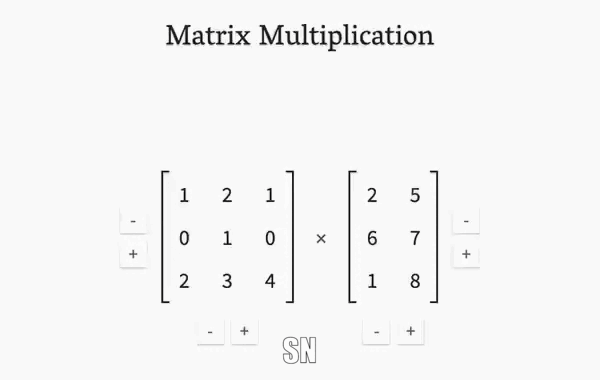

##### Trenowanie modelu

Liniowy model dla więcej niż jednej zmiennej objaśniającej zapiszemy w postaci macierzowej: $$\hat{y} = w^T x + b$$ Jednak w tej sytuacji $w$ oraz $b$ mogą być macierzami: $$\hat{y} = \begin{bmatrix}
x_1\\
x_2
\end{bmatrix}^T  \begin{bmatrix}
w_1\\
w_2
\end{bmatrix} + \begin{bmatrix}
b
\end{bmatrix}$$ P.S. Jeśli chcielibyśmy predykować także inną zmienną to również y byłby macierzą. <br> Możemy napisać to w bardziej skondensowanej formie gdzie włączymy parametr $b$ do macierzy $w$ (proszę zwrócić uwagę na liczbę 1 włączoną do macierzy x):
$$\hat{y} = \begin{bmatrix}
\textbf{1}\\
x_1\\
x_2
\end{bmatrix}^T  \begin{bmatrix}
w_0\\
w_1\\
w_2
\end{bmatrix}$$
Macierz $w$ wraz z wszystkimi jej wartościami to **parametry** modelu - to miejsce gdzie znajduje się cała "wiedza" modelu.  Teraz zdefiniujmy funkcję kosztu - MSE (mean squared error): $$J = \frac{1}{n} \sum_{i=1}^{n} (\hat{y} - y)^2$$ Czym większa będzie różnica między $\hat{y}$ (czyli ceną predykowaną przez nasz model) a $y$ (czyli prawdziwą ceną) - tym większy będzie błąd/funkcja kosztu. To co chcemy zrobić to znaleźć minimum tej funckji. I tutaj z pomocą przychodzi analiza matematyczna oraz pochodne - musimy wyzerować pochodną tej funkcji. Przypomnienie pochodnych na przykładzie funkcji kwadratowej:

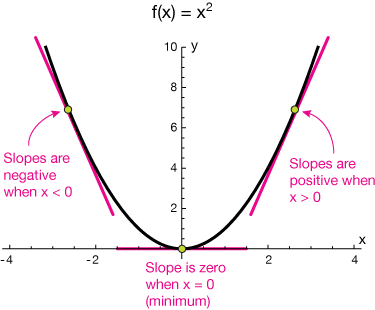

Po przyrównaniu pochodnej do zera możemy analitycznie wyliczyć wartości parametrów w zależności od y i x:
$$ w = (X^TX)^{-1}X^TY $$

##### Proszę wyliczyć macierz $w$ na podstawie powyższego wzoru 

przydatne funkcje oraz notacje: <br>
**@** - mnożenie macierzowe<br>
**X.T** - transpozycja macierzy (jeśli X jest macierzą) <br>
**np.linalg.inv** - funkcja z biblioteki numpy do odwracania macierzy

In [ ]:
X_org = df[['sqft_living', 'bedrooms']].to_numpy()
# dodajmy kolumnę samych jedynek do x
X_shape = list(X_org.shape)
X_shape[-1] = 1
X = np.concatenate([np.ones(X_shape), X_org], axis=-1)

Y = df['price'].to_numpy()
print(f"Wymiar X to {X.shape}, zaś Y to {Y.shape}")
# proszę poniżej kontynuować kod

In [ ]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Przetłumacz wzór $w = (X^TX)^{-1}X^TY$ na Python krok po kroku:

- `X.T` → transpozycja macierzy
- `@` → mnożenie macierzowe  
- `np.linalg.inv(...)` → odwrócenie macierzy

Spróbuj złożyć to w jedną linię kodu.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
# rozwiązanie
w = np.linalg.inv(X.T @ X) @ X.T @ Y
#https://aunnnn.github.io/ml-tutorial/html/blog_content/linear_regression/linear_regression_tutorial.html

In [ ]:
w

###### Zbudowanie prostej klasy

In [ ]:
class LinearModelMulti():
    def __init__(self, w):
        self.w = w
        
    def __call__(self, X):
        X = np.array(X)
        if isinstance(X, np.ndarray) and len(X.shape)==1:
            X = X.reshape(1,-1)
        X_shape = list(X.shape)
        X_shape[-1] = 1
        X = np.concatenate([np.ones(X_shape), X], axis=-1)
        return X @ self.w


try:
    # Proszę wpisać odpowiedni parametr w wywołaniu tej klasy
    linear_model = LinearModelMulti(None)
except NameError:
    print(f"{bcolors.BOLD}{bcolors.FAIL}Proszę sprawdzić czy została przypisana wartość do parametru w{bcolors.ENDC}")
else:
    result = linear_model(X_org[0:5,:])
    strFormat = len(result) * '{:0.3f} '
    formatted_results = strFormat.format(*result)
    print(f"Dla pierwszych 4 wierszy predykujemy następujące ceny: [{formatted_results}]")

<span style="font-family:Monospace">Dla pierwszych 4 wierszy predykujemy następujące ceny: [278728.533 715117.204 207076.331 466541.748 435702.875 ]</span>

In [ ]:
# Do wizualizacji weźmiemy tylko 100 pierwszych wierszy
df_small = df.iloc[:100,:]
X1 =df_small['sqft_living']
X2 =df_small['bedrooms']
Y =df_small['price']

X1_plane, X2_plane = np.meshgrid(X1, X2)
model_input = np.stack((X1_plane,X2_plane), axis=-1)
Y_plane = linear_model(model_input)

fig = go.Figure(data=[go.Surface(z=Y_plane, x=X1_plane, y=X2_plane, opacity=0.005), go.Scatter3d(x=X1, y=X2, z=Y, mode='markers')])

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0))

##### Zadanie dodatkowe - przekopiować powyższą implementację klasy LinearModelMulti i dodać do niej metodę .fit , która dla nowych danych uczących wyznaczy nowe parametry modelu liniowego, oraz zmienić metodą __call__ na predict

In [ ]:
# Tutaj wpisz swój kod


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Wzoruj się na istniejącej klasie `LinearModelMulti` powyżej. W metodzie `fit(self, X, Y)`:

1. `X = np.array(X)`
2. Dodaj kolumnę jedynek tak jak w komórce wyżej: `np.concatenate([np.ones(...), X], axis=-1)`
3. Oblicz `self.w` wzorem z poprzedniego zadania

W metodzie `predict` sprawdź czy `self.w is not None` zanim policzysz wynik.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [ ]:
# przykładowe rozwiązanie
class LinearModelMulti():
    def __init__(self):
        self.w = None
        
    @staticmethod
    def stack_ones(X):
        X_shape = list(X.shape)
        X_shape[-1] = 1
        return np.concatenate([np.ones(X_shape), X], axis=-1)
        
    def fit(self, X, Y):
        X = np.array(X)
        X = self.stack_ones(X)
        Y = np.array(Y)
        self.w = np.linalg.inv(X.T @ X) @ X.T @ Y
        
    def predict(self, X):
        if self.w is None:
            raise NotFittedError 
        X = np.array(X)
        if isinstance(X, np.ndarray) and len(X.shape)==1:
            X = X.reshape(1,-1)
        X = self.stack_ones(X)
        return X @ self.w

##### Sprawdźmy poniżej czy nasz model jako klasa działa. Zaproponowane tutaj funkcje (fit, predict) są również używane przez jedną z najpopularniejszych bibliotek zawierających modele w pythonie - scikit-learn

In [ ]:
linear_model = LinearModelMulti()
linear_model.fit(df[['sqft_living', 'bedrooms']], df['price'])
linear_model.predict([[1050, 2], [2100, 4], [750, 3]])

<span style="font-family:Monospace">array([294981.9623291 , 510494.56425758, 143730.59880693])</span>

## Regresja wielomianowa oraz overfitting

Skoro już użyliśmy modelu liniowego to można się zastanowić nad modelem np. kwadratowym: $$\hat{y} = a_2 \cdot x^2 + a_1 \cdot x + a_0$$ Skoro tak to może nawet użyjmy jeszcze kolejnych rozwinieć wielomianu: $$\hat{y} = a_k \cdot x^k + ... + a_2 \cdot x^2 + a_1 \cdot x + a_0$$ W notacji macierzowej: $$\hat{y} = \begin{bmatrix}
\textbf{1}, x, x^2, ..., x^k
\end{bmatrix}  \begin{bmatrix}
a_0\\
a_1\\
a_2\\
...\\
a_k
\end{bmatrix} = 
\begin{bmatrix}
\textbf{1}\\
x\\
x^2\\
...\\
x^k
\end{bmatrix}^T  \begin{bmatrix}
w_0\\
w_1\\
w_2\\
...\\
w_k
\end{bmatrix}$$
Co ciekawe możemy traktować kolejne potęgi x jako nowe zmienne, wtedy model wygląda tak samo jak model liniowy tylko z większą liczbą parametrów do wytrenowania. Właśnie przez stworzenie nowych zmiennych zaimplementujemy to w pythonie ale wykorzystamy tylko jedną zmienną objaśniającą - powierzchnię mieszkania (sqrt_living). Ustawimy liczbę wielomianu na 4. Jeśli ktoś ma klasę LinearModelMulti z metodami fit i predict może użyć swojej - jeśli nie to proszę wywołać komórkę z przygotowanym rozwiązaniem

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
y = df['price'].to_numpy().reshape(-1, 1)
x = df['sqft_living'].to_numpy().reshape(-1, 1)
poly_reg=PolynomialFeatures(degree=4)
x_poly=poly_reg.fit_transform(x)
#usuwamy pierwszy wymiar z polynomial_x ponieważ pierwszy wymiar to x^0 czyli same jedynki
x_poly = x_poly[:,1:]
print(f"Wymiar naszego oryginalnego x wynosił: {x.shape}, po dodaniu kolejnych potęg: {x_poly.shape}")

**jeśli została zaimplementowana poprawnie klasa LinerModelMulti proszę wywołać następującą linijkę:**

In [ ]:
linear_model = LinearModelMulti()
#jeśli nie została zaimplementowana własna klasa LinerModeMulti to proszę zakomentować powyższą linijkę 
#i odkomentować tę poniżej
# linear_model = SklearnLinearRegression()
linear_model.fit(x_poly, y)
pred=linear_model.predict(x_poly)
mean_squared_error=metrics.mean_squared_error(y,pred)
print('Root mean squared error (RMSE)', round(np.sqrt(mean_squared_error),2))

<span style="font-family:Monospace">Root mean squared error (RMSE) 248601.08</span>

Jeśli zadanie regresji liniowej 2D zostało poprawnie wykonane to dla zmiennej objaśniającej powierzchnia mieszkania mieliśmy MSE wynoszące 261440,79. Zatem teraz mamy mniej - chyba to dobrze, gdyż chcemy minimalizować MSE. Otóż niekoniecznie - może być to symptomem overfittingu czyli zbytniego dopasowania się dodanych treningowych. Zobaczmy jak to wygląda na wykresach przedstawiających model po dodawaniu kolejnych potęg do modelu

In [ ]:
number=6
rows = int(np.ceil(number/2))
fig,axes = plt.subplots(nrows=rows,ncols=2, figsize=(18,12))
axes = axes.flatten()
down = 10
up = 20

for i in range(number):

    y_small = df.loc[down:up,['price']].to_numpy().reshape(-1, 1)
    x_small = df.loc[down:up,['sqft_living']].to_numpy().reshape(-1, 1)
    poly_reg=PolynomialFeatures(degree=i+1)
    x_poly_small=poly_reg.fit_transform(x_small)
    x_poly_small = x_poly_small[:,1:]
    linear_model.fit(x_poly_small, y_small)
    pred=linear_model.predict(x_poly_small)
    mean_squared_error=metrics.mean_squared_error(y_small,pred)

    x_lin = np.linspace(min(x_small), max(x_small))
    x_input = poly_reg.fit_transform(x_lin)[:,1:]
    y_lin = linear_model.predict(x_input)

    axis = axes[i]
    axis.scatter(x_small, y_small)
    axis.plot(x_lin, y_lin, color='r')
    axis.set(xlabel='sqft_living', ylabel='price')
    red_patch = mpatches.Patch(color='red', label='Model')
    blue_patch = mpatches.Patch(color='#1f77b4', label='Real data')
    axis.legend(handles=[red_patch, blue_patch])
    mse = int(mean_squared_error)
    axis.set_title(f"Wielomian stopnia {i+1}. MSE: {format(mse, ',d').replace(',',' ')}.{str(mean_squared_error-mse)[2:4]}")
fig.tight_layout(pad=2.0)

Jak widać będziemy musieli jakoś poradzić sobie ze zbytnim dopasowaniem do danych, ale jakie są na to metody dowiemy się w następnym laboratorium

### Szkice

In [ ]:
#Wykres 3D w matplotlib
%matplotlib notebook
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

df_small = df.iloc[:100,:]

# axes instance
fig = plt.figure(figsize=(6,6))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

# get colormap from seaborn
cmap = ListedColormap(sns.color_palette("husl", 256).as_hex())

# plot
sc = ax.scatter(df_small['sqft_living'], df_small['bedrooms'], df_small['price'], s=40, marker='o', alpha=1)
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

# legend
plt.legend(*sc.legend_elements(), bbox_to_anchor=(1.05, 1), loc=2)

In [ ]:
#Wykres 3D w matplitlib z płaszczyzną
%matplotlib notebook

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d  
from matplotlib import cm 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

x =df['sqft_living'][:50]
y =df['bedrooms'][:50]
z =df['price'][:50]

ax.scatter(x, y, z, c='r', marker='o')

train_data = df
features1=['sqft_living','bedrooms']
reg=SklearnLinearRegression()
reg.fit(train_data[features1],train_data['price'])


X_plane, Y_plane = np.meshgrid(x, y)
# pred=reg.predict(X_plane, Y_plane)
Z_plane = (reg.coef_[0] * X_plane) + (reg.coef_[1] * Y_plane) + reg.intercept_
ax.plot_surface(X_plane,Y_plane, Z_plane, rstride=1, cstride=1, cmap=cm.coolwarm, alpha=0.5)
# plot3D.plot_surface(X_plane,Y_plane, pred, rstride=1, cstride=1, cmap=cm.coolwarm)